In [1]:
#Data Loading

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

try:
    df = pd.read_csv("final_preprocessed_dataset.csv")
    print(f"Dataset loaded. Original shape: {df.shape}")
except FileNotFoundError:
    print("ERROR: 'final_preprocessed_dataset.csv' file not found.")
    exit()

original_count = len(df)
df.dropna(subset=['Depression'], inplace=True)
print(f"Removed {original_count - len(df)} rows with missing 'Depression' values.")

X = df.drop('Depression', axis=1)
y = df['Depression']
print("Data loading and preparation complete.")

Dataset loaded. Original shape: (22301, 30)
Removed 0 rows with missing 'Depression' values.
Data loading and preparation complete.


In [2]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nTarget distribution (counts & ratio):")
cnt = df['Depression'].value_counts().sort_index()
print(cnt)
print((cnt / cnt.sum()).round(4))


Shape: (22301, 30)

Columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'PC21', 'PC22', 'PC23', 'PC24', 'PC25', 'PC26', 'PC27', 'PC28', 'PC29', 'Depression']

Target distribution (counts & ratio):
Depression
0     9168
1    13133
Name: count, dtype: int64
Depression
0    0.4111
1    0.5889
Name: count, dtype: float64


In [3]:
#Data Splitting

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data successfully splited")

Data successfully splited


In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN model
knn = KNeighborsClassifier()

# Define parameter grid for K values (you can adjust the range as needed)
param_grid = {
    'n_neighbors': list(range(1, 30)),
    'weights': ['uniform', 'distance']  # small but meaningful extra variety
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Get the best parameters and estimator
best_k = grid_search.best_params_['n_neighbors']
best_model = grid_search.best_estimator_

best_w = grid_search.best_params_['weights']
print(f"Best weights: {best_w}")

print(f"Best K value found: {best_k}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Evaluate on test data
test_accuracy = best_model.score(X_test, y_test)
print(f"Test set accuracy with best K: {test_accuracy:.4f}")


Best weights: distance
Best K value found: 12
Best cross-validation accuracy: 0.8137
Test set accuracy with best K: 0.8117


In [5]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = best_model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[1336  498]
 [ 342 2285]]
              precision    recall  f1-score   support

           0       0.80      0.73      0.76      1834
           1       0.82      0.87      0.84      2627

    accuracy                           0.81      4461
   macro avg       0.81      0.80      0.80      4461
weighted avg       0.81      0.81      0.81      4461



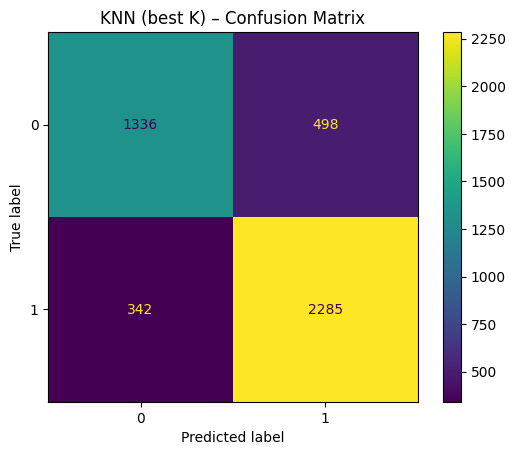

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import label_binarize

# Confusion matrix heatmap
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
ax.set_title("KNN (best K) – Confusion Matrix")
plt.show()




[[1336  498]
 [ 342 2285]]
              precision    recall  f1-score   support

           0       0.80      0.73      0.76      1834
           1       0.82      0.87      0.84      2627

    accuracy                           0.81      4461
   macro avg       0.81      0.80      0.80      4461
weighted avg       0.81      0.81      0.81      4461

ROC–AUC Score: 0.8815


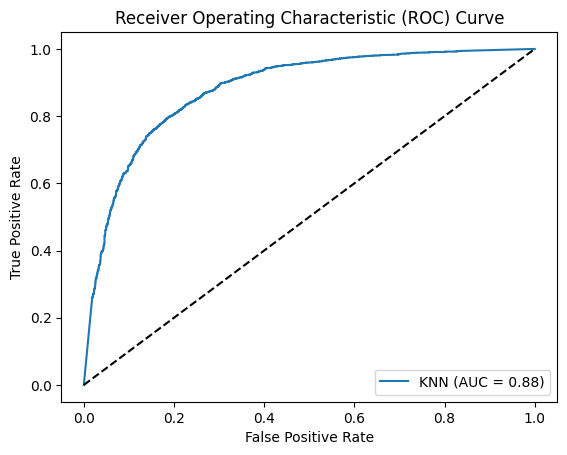

In [9]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ---- ROC–AUC Curve ----
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_pred_prob = best_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC–AUC Score: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


In [ ]:
import joblib, pandas as pd
joblib.dump(best_model, "knn_best_model.joblib")
pd.DataFrame(grid_search.cv_results_).to_csv("knn_cv_results.csv", index=False)
